In [ ]:
# Prevent OpenMP/MKL thread conflicts with PyTorch backend
from __future__ import annotations

import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

'1'

## General Steps:
1. Create SentimentAnalysis Game with fixed input text  
(Distilbert model (from HF) does the tokenization and output classification result)
2. Compute shapley values
3. Do sentence Plot 

In [2]:
import shapiq
from shapiq_games.benchmark import SentimentAnalysisLocalXAI

/var/folders/z4/qt_tp8rs5gz63c5bp4cryrs00000gn/T/ipykernel_6824/2180768767.py:2: DeprecationWarning: This collection of games is deprecated and will be removed in a future version.
  from shapiq_games.benchmark import SentimentAnalysisLocalXAI


## Positive Example

## 1.Create Game

In [3]:
game = SentimentAnalysisLocalXAI(
    input_text="I really loved this amazing film",
    mask_strategy="mask",
    normalize=True,
)

token_names = game.input_text.split()

print(token_names)
print(game.n_players)
print(game.grand_coalition_value)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

['i', 'really', 'loved', 'this', 'amazing', 'film']
6
0.47168368101119995


## 2.Compute Shapley values

In [4]:
approx = shapiq.KernelSHAP(n=game.n_players, random_state=42)
sv = approx.approximate(budget=50, game=game)

print(sv)

InteractionValues(
    index=SV, max_order=1, min_order=0, estimated=True, estimation_budget=50,
    n_players=6, baseline_value=0.0,
    Top 10 interactions:
        (4,): 0.15584698643035844
        (2,): 0.14672763815828355
        (1,): 0.13720915597081024
        (0,): 0.043158132522665475
        (5,): 0.007910929849371818
        (): 0.0
        (3,): -0.01916915923884025
)


## Plot

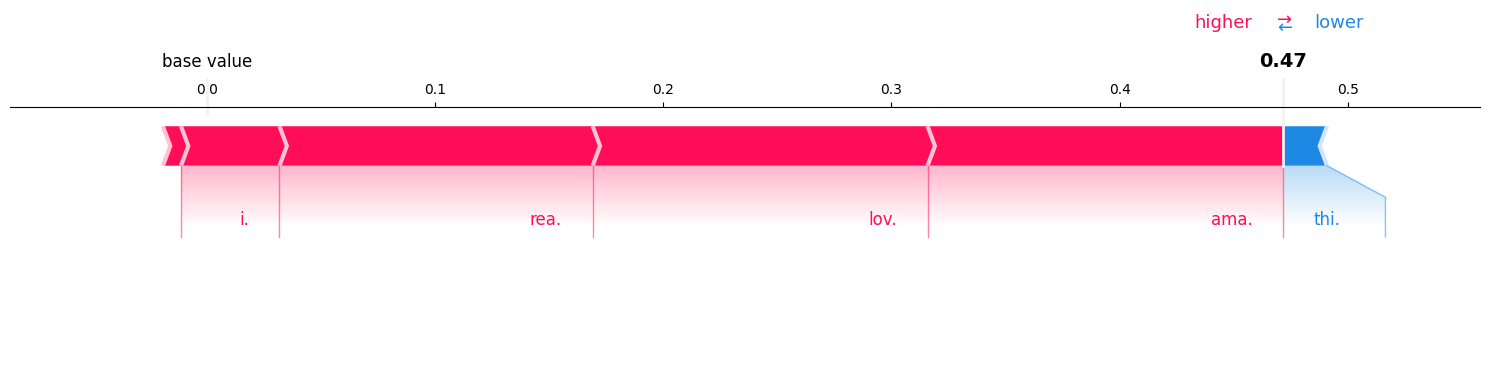

In [5]:
sv.plot_force(feature_names=token_names)

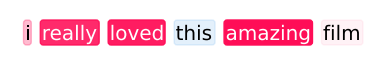

In [11]:
sv.plot_sentence(words=token_names)

2nd order interaction

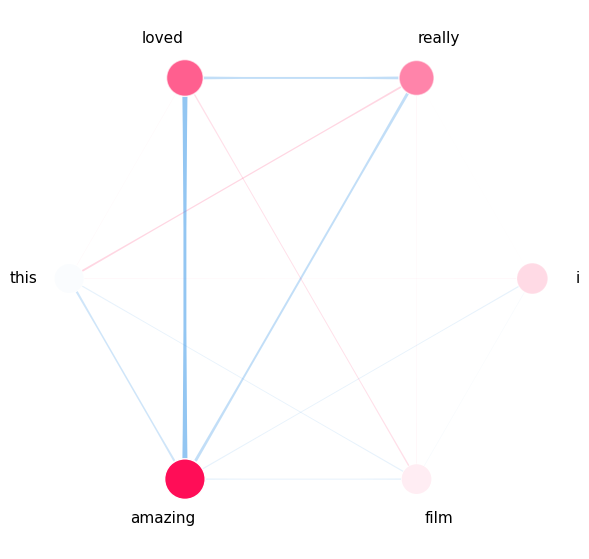

In [6]:
approx_sii = shapiq.KernelSHAPIQ(
    n=game.n_players,
    index="k-SII",
    max_order=2,
    random_state=42,
)

sii = approx_sii.approximate(budget=50, game=game)
sii.plot_network(feature_names=token_names)

## Negative example

## 1.Create SentimentAnalysisGame

In [7]:
game_neg = SentimentAnalysisLocalXAI(
    input_text="This movie was terrible and boring",
    mask_strategy="mask",
    normalize=True,
)

token_names_neg = game_neg.input_text.split()

print(token_names_neg)
print(game_neg.grand_coalition_value)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

['this', 'movie', 'was', 'terrible', 'and', 'boring']
-1.52092444896698


## 2.Compute Shapley Values

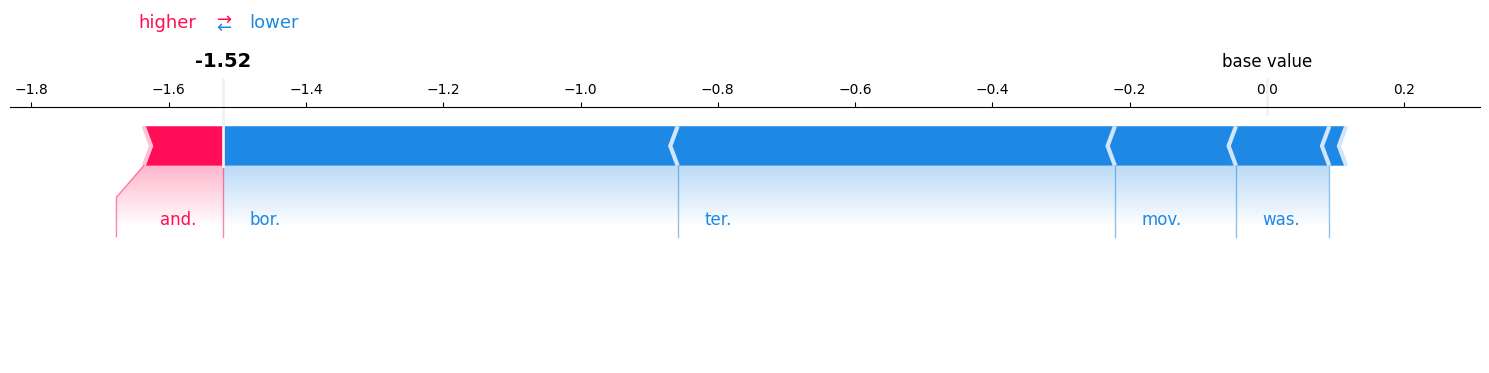

In [ ]:
sv_neg = shapiq.KernelSHAP(n=game_neg.n_players, random_state=42).approximate(
    budget=50,
    game=game_neg,
)

## 3.Plot

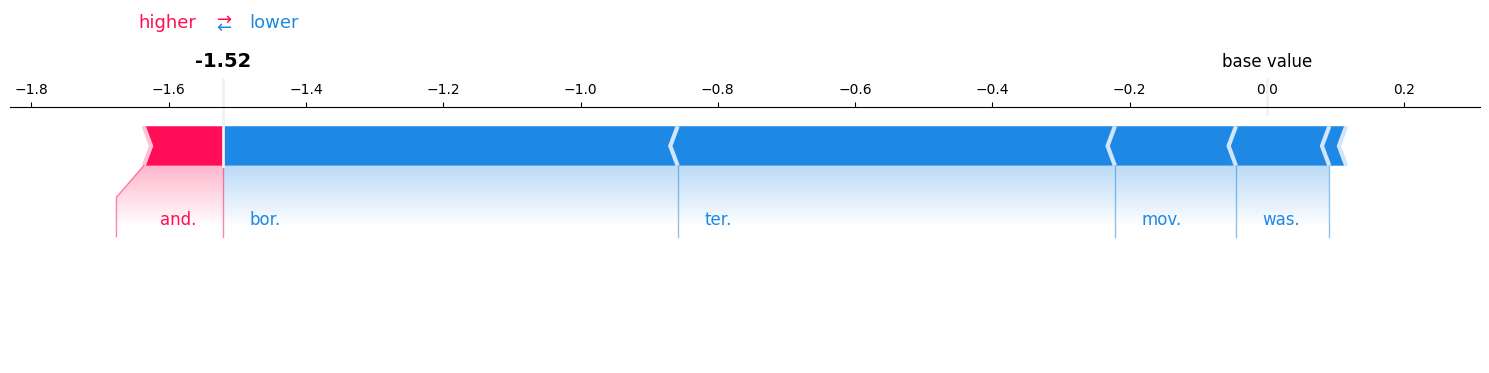

In [12]:
sv_neg.plot_force(feature_names=token_names_neg)

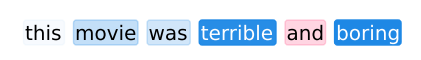

In [10]:
sv_neg.plot_sentence(words=token_names_neg)